# EDA — BDNB Data Sources

Quick exploratory analysis of the two raw inputs used by the ETL pipeline:
- **`batiment_groupe.csv`** — building group footprints (geometry + identifiers)
- **`batiment_groupe_ffo_bat.csv`** — Fichiers Fonciers metadata (construction year, levels, usage, materials)

In [9]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")

ROOT = Path(r"C:\Users\felip\data_projects\dv-paris-arbres")
GEOM_CSV  = str(ROOT / "data/raw/csv/batiment_groupe.csv")
META_CSV  = str(ROOT / "data/raw/csv/batiment_groupe_ffo_bat.csv")

conn = duckdb.connect()

geom_df = conn.execute(f"SELECT * FROM read_csv_auto('{GEOM_CSV}')").df()
meta_df = conn.execute(f"SELECT * FROM read_csv_auto('{META_CSV}')").df()

print("Geometry CSV:", geom_df.shape)
print("FFO metadata CSV:", meta_df.shape)

Geometry CSV: (74132, 9)
FFO metadata CSV: (70723, 8)


## 1. Geometry Source — `batiment_groupe.csv`

In [10]:
# Schema + missing values
print("=== dtypes ===")
print(geom_df.dtypes.to_string())
print("\n=== Missing values ===")
missing = geom_df.isnull().sum()
print(missing[missing > 0].to_string() or "None")

=== dtypes ===
geom_groupe                       str
batiment_groupe_id                str
code_departement_insee          int64
s_geom_groupe                   int64
code_iris                       int64
code_commune_insee              int64
libelle_commune_insee             str
code_epci_insee                 int64
contient_fictive_geom_groupe    int64

=== Missing values ===
Series([], )


In [11]:
empty_geom = (geom_df["geom_groupe"].str.strip() == "").sum()
print(f"Empty geometry strings: {empty_geom}")
print(f"Non-null geometry: {geom_df['geom_groupe'].notna().sum()} / {len(geom_df)}")
print(f"\nSample WKT value:\n{geom_df['geom_groupe'].iloc[0][:120]}...")

Empty geometry strings: 0
Non-null geometry: 74132 / 74132

Sample WKT value:
MULTIPOLYGON (((652830.7 6862597.6,652829.0 6862595.1,652834.9 6862590.7,652835.2 6862590.5,652842.4 6862599.8,652836.3 ...


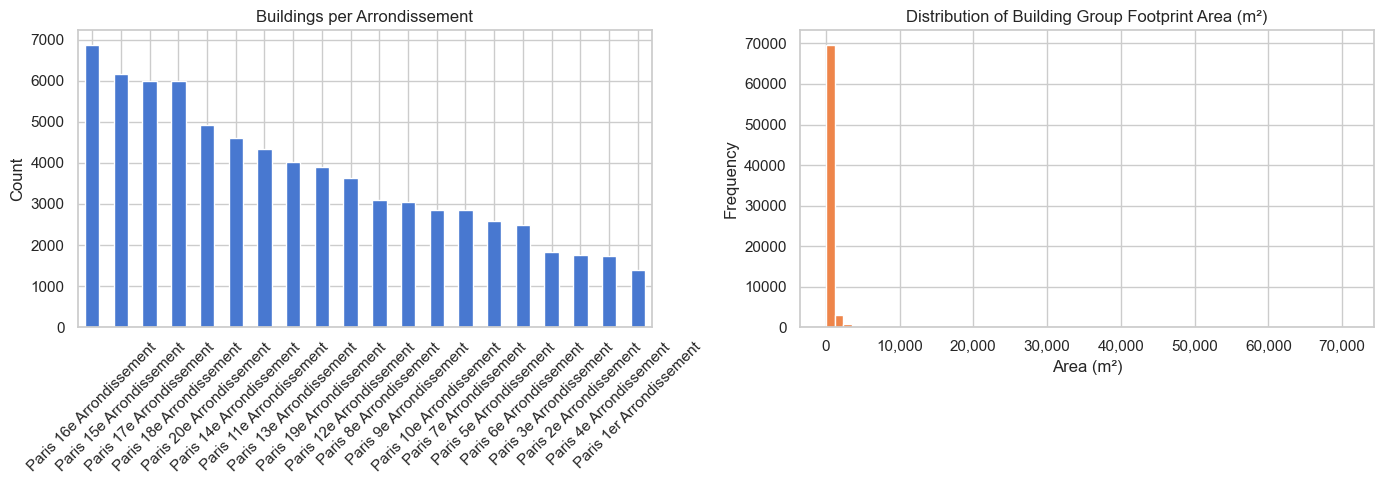

In [12]:
# Buildings per arrondissement (commune)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Buildings per commune
commune_counts = (
    geom_df.groupby("libelle_commune_insee")
    .size()
    .sort_values(ascending=False)
)
commune_counts.plot(kind="bar", ax=axes[0], color=sns.color_palette("muted")[0])
axes[0].set_title("Buildings per Arrondissement")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Footprint area distribution (s_geom_groupe in m²)
geom_df["s_geom_groupe"].dropna().plot(
    kind="hist", bins=60, ax=axes[1], color=sns.color_palette("muted")[1], edgecolor="white"
)
axes[1].set_title("Distribution of Building Group Footprint Area (m²)")
axes[1].set_xlabel("Area (m²)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

## 2. FFO Metadata — `batiment_groupe_ffo_bat.csv`

In [13]:
# Schema + descriptive stats + missing values
print("=== dtypes ===")
print(meta_df.dtypes.to_string())
print("\n=== Descriptive stats ===")
print(meta_df.describe().to_string())
print("\n=== Missing values (%) ===")
pct = (meta_df.isnull().mean() * 100).round(1).sort_values(ascending=False)
print(pct[pct > 0].to_string())

=== dtypes ===
batiment_groupe_id          str
code_departement_insee    int64
nb_niveau                 int64
annee_construction        Int64
usage_niveau_1_txt          str
mat_mur_txt                 str
mat_toit_txt                str
nb_log                    int64

=== Descriptive stats ===
       code_departement_insee     nb_niveau  annee_construction        nb_log
count                 70723.0  70723.000000             65367.0  70723.000000
mean                     75.0      5.887632         1903.082656     20.083961
std                       0.0      2.555744           65.271976     38.206883
min                      75.0      1.000000              1200.0      0.000000
25%                      75.0      5.000000              1880.0      5.000000
50%                      75.0      7.000000              1900.0     13.000000
75%                      75.0      7.000000              1933.0     22.000000
max                      75.0     58.000000              2024.0   3089.000000


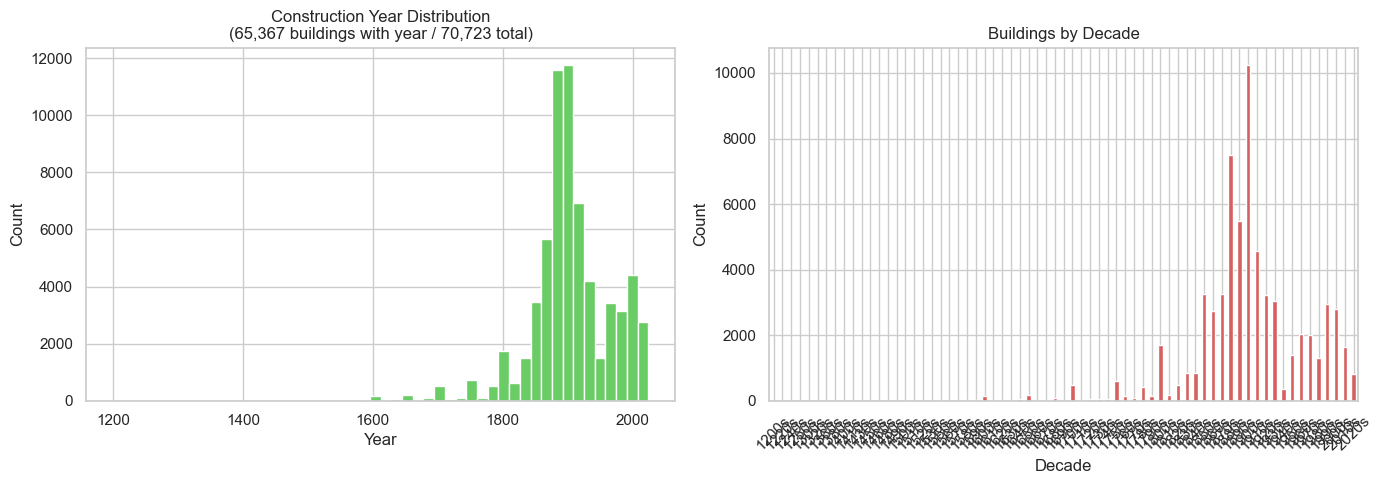

In [14]:
# Construction year distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

year_data = meta_df["annee_construction"].dropna()

# Histogram
year_data.plot(kind="hist", bins=50, ax=axes[0], color=sns.color_palette("muted")[2], edgecolor="white")
axes[0].set_title(f"Construction Year Distribution\n({year_data.notna().sum():,} buildings with year / {meta_df.shape[0]:,} total)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")

# Decade aggregation
decade_counts = (
    year_data
    .apply(lambda y: f"{int(y)//10*10}s")
    .value_counts()
    .sort_index()
)
decade_counts.plot(kind="bar", ax=axes[1], color=sns.color_palette("muted")[3], edgecolor="white")
axes[1].set_title("Buildings by Decade")
axes[1].set_xlabel("Decade")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

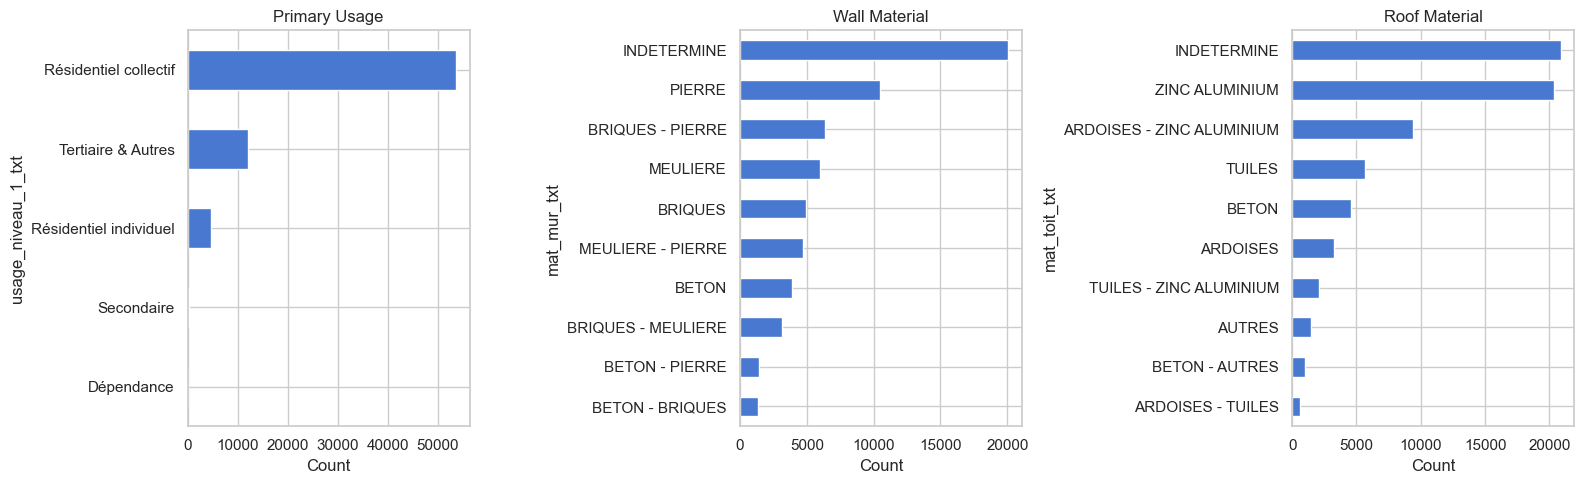

In [15]:
# Categorical breakdowns: usage, wall material, roof material
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cat_cols = [
    ("usage_niveau_1_txt", "Primary Usage"),
    ("mat_mur_txt",        "Wall Material"),
    ("mat_toit_txt",       "Roof Material"),
]

for ax, (col, title) in zip(axes, cat_cols):
    counts = meta_df[col].value_counts().head(10)
    counts.plot(kind="barh", ax=ax, color=sns.color_palette("muted")[0])
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

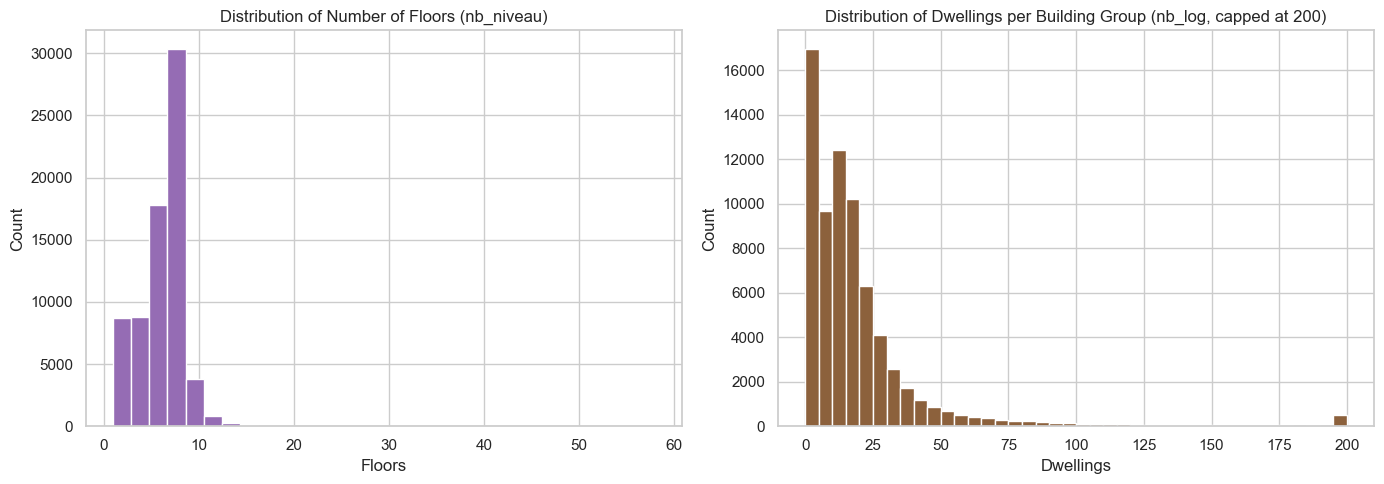

In [16]:
# Number of floors + number of dwellings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

meta_df["nb_niveau"].dropna().plot(
    kind="hist", bins=30, ax=axes[0], color=sns.color_palette("muted")[4], edgecolor="white"
)
axes[0].set_title("Distribution of Number of Floors (nb_niveau)")
axes[0].set_xlabel("Floors")
axes[0].set_ylabel("Count")

meta_df["nb_log"].dropna().clip(upper=200).plot(
    kind="hist", bins=40, ax=axes[1], color=sns.color_palette("muted")[5], edgecolor="white"
)
axes[1].set_title("Distribution of Dwellings per Building Group (nb_log, capped at 200)")
axes[1].set_xlabel("Dwellings")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()